In [1]:
from Functions import p_lambda_ang_iso, p_lambda_ang_aniso_y, p_lambda_ang_aniso_z 
import matplotlib.pyplot as plt
import numpy as np
import pickle
import os

In [52]:
def load_data(dirpath):
    data = {}
    for i in range(29):
        filename = f"G2_{i:02d}_withEDM.pkl"
        
        phi = 2*np.pi*i/29

        filepath = os.path.join(dirpath, filename)
        with open(filepath, "rb") as f:
            lam, theta, Z = pickle.load(f)

        data[i] = [lam, theta, Z, phi]
    return data

def polarisation(phi, delta):
    return [
        np.sin(phi)*np.cos(delta),
        np.sin(phi)*np.sin(delta),
        np.cos(phi)
    ]

def p(theta, lam, phi, delta, beta = -0.9994):
    pol = polarisation(phi, delta)
    return p_lambda_ang_iso(lam, theta, beta) + p_lambda_ang_aniso_y(lam,theta,beta,pol[1]) + p_lambda_ang_aniso_z(lam,theta,beta,pol[2])

In [59]:
def NLL(deltas, data_dict):
    deltas = np.asarray(deltas)
    N = deltas.size

    total = np.zeros(N)
    per_run = {}

    for run_id, (lam, theta, Z, phi) in data_dict.items():
        p_curr = p(theta[..., None], lam[..., None], phi, deltas)
        p_safe = np.clip(p_curr, 1e-300, None)

        mask2 = (Z > 0) & np.isfinite(Z)
        Z_flat = Z.reshape(-1)
        P_flat = p_safe.reshape(-1, N)
        mask_flat = mask2.reshape(-1)

        Zk = Z_flat[mask_flat].astype(float)
        Pk = P_flat[mask_flat, :].astype(float)

        Zk /= Zk.sum()
        Pk /= Pk.sum(axis=0, keepdims=True)

        log_diff = np.log(Zk)[:, None] - np.log(Pk)
        nll_run = np.sum(log_diff**2, axis=0)

        per_run[run_id] = nll_run
        total += nll_run

    return total, per_run


data = load_data("data/With EDM")
deltas = np.linspace(1e-3, 0.5, 200)
NLL_total, NLL_runs = NLL(deltas, data)

for d, nll in zip(deltas, NLL_total):
    print(f"NLL({d:.3g}) = {nll:.3g}")

NLL(0.001) = 1.68e+04
NLL(0.00351) = 1.67e+04
NLL(0.00602) = 1.66e+04
NLL(0.00852) = 1.65e+04
NLL(0.011) = 1.64e+04
NLL(0.0135) = 1.63e+04
NLL(0.016) = 1.62e+04
NLL(0.0186) = 1.61e+04
NLL(0.0211) = 1.6e+04
NLL(0.0236) = 1.59e+04
NLL(0.0261) = 1.58e+04
NLL(0.0286) = 1.57e+04
NLL(0.0311) = 1.56e+04
NLL(0.0336) = 1.55e+04
NLL(0.0361) = 1.54e+04
NLL(0.0386) = 1.53e+04
NLL(0.0411) = 1.53e+04
NLL(0.0436) = 1.52e+04
NLL(0.0461) = 1.51e+04
NLL(0.0486) = 1.5e+04
NLL(0.0512) = 1.49e+04
NLL(0.0537) = 1.48e+04
NLL(0.0562) = 1.48e+04
NLL(0.0587) = 1.47e+04
NLL(0.0612) = 1.46e+04
NLL(0.0637) = 1.45e+04
NLL(0.0662) = 1.44e+04
NLL(0.0687) = 1.44e+04
NLL(0.0712) = 1.43e+04
NLL(0.0737) = 1.42e+04
NLL(0.0762) = 1.41e+04
NLL(0.0787) = 1.41e+04
NLL(0.0812) = 1.4e+04
NLL(0.0837) = 1.39e+04
NLL(0.0863) = 1.38e+04
NLL(0.0888) = 1.38e+04
NLL(0.0913) = 1.37e+04
NLL(0.0938) = 1.36e+04
NLL(0.0963) = 1.36e+04
NLL(0.0988) = 1.35e+04
NLL(0.101) = 1.34e+04
NLL(0.104) = 1.34e+04
NLL(0.106) = 1.33e+04
NLL(0.109) = 1.32

delta_hat = 0.2918743718592965 NLL_min = 10906.486979096437


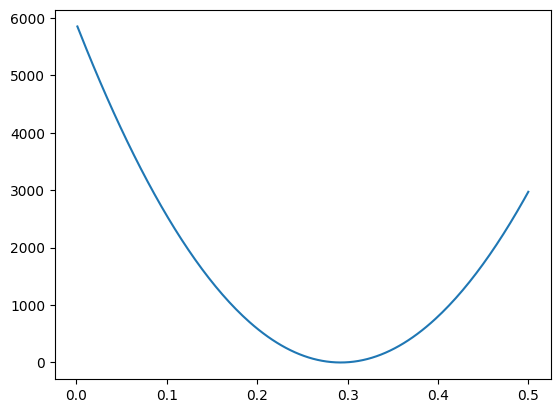

In [60]:
idx = np.argmin(NLL_total)
delta_hat = deltas[idx]
nll_min = NLL_total[idx]

deltaNLL = NLL_total - nll_min
print("delta_hat =", delta_hat, "NLL_min =", nll_min)
plt.plot(deltas, deltaNLL)

In [61]:
left = deltas[(deltaNLL >= 1) & (deltas < delta_hat)].max()
right = deltas[(deltaNLL >= 1) & (deltas > delta_hat)].min()

err_minus = delta_hat - left
err_plus = right - delta_hat
err = 0.5 * (err_plus + err_minus)
err

np.float64(0.00501507537688442)

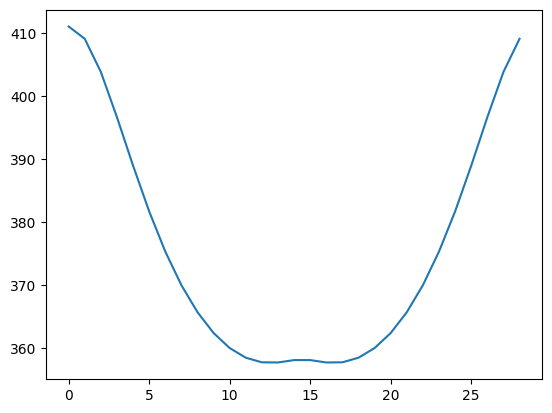

In [65]:
run_ids = range(29)

NLL_idk = []
delta_idk = []

for rid in run_ids:
    nll_curve = NLL_runs[rid]
    i_min = np.argmin(nll_curve)

    NLL_idk.append(nll_curve[i_min])
    delta_idk.append(deltas[i_min])

plt.plot(run_ids, NLL_idk)